# Research Question 3 — Autonomic Aging Dataset




In [1]:
import os
import numpy as np
import pandas as pd
import wfdb
import neurokit2 as nk

import matplotlib.pyplot as plt
from tqdm import tqdm

from scipy.stats import chi2, skew
from sklearn.preprocessing import StandardScaler

from pathlib import Path




In [2]:
# -------------------------
# Configuration
# -------------------------
FIG_DIR = Path("Figures/Chapter7")
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = "./dataset"  
WINDOW_SECONDS = 60     # window length 
MAX_WINDOWS = 5         # number of windows per record (runtime control)

# Quality thresholds: require at least this many windows to yield valid ECG/BP features
MIN_VALID_ECG_WINDOWS = 3
MIN_VALID_BP_WINDOWS  = 3

# Physiological plausibility bounds (used to filter ECG-derived HR estimates)
HR_MIN = 35
HR_MAX = 200


In [3]:
def safe_nanmean(arr):
    """Mean that returns NaN if all values are NaN."""
    arr = np.asarray(arr, dtype=float)
    return float(np.nanmean(arr)) if np.isfinite(arr).any() else np.nan

def pick_first_present(sig_names, candidates):
    """Return (index, name) of the first candidate channel that exists in sig_names."""
    for c in candidates:
        if c in sig_names:
            return sig_names.index(c), c
    return None, None

def ecg_hr_sdnn_from_ecg_process(ecg, fs):
    """Compute mean HR (bpm) and SDNN (ms) from ECG using NeuroKit's full ecg_process."""
    ecg = np.asarray(ecg, dtype=np.float64)
    ecg = ecg[np.isfinite(ecg)]
    if ecg.size < fs * 5:
        return np.nan, np.nan

    try:
        _, info = nk.ecg_process(ecg, sampling_rate=fs)
        r = info.get("ECG_R_Peaks", None)
        if r is None:
            return np.nan, np.nan
        r = np.asarray(r, dtype=int)
    except Exception:
        return np.nan, np.nan

    if r.size < 10:
        return np.nan, np.nan

    rr = np.diff(r) / fs  # seconds
    rr = rr[(rr >= 0.3) & (rr <= 2.0)]  # plausibility filter
    if rr.size < 5:
        return np.nan, np.nan

    hr_mean = 60.0 / np.mean(rr)
    if not (HR_MIN <= hr_mean <= HR_MAX):
        return np.nan, np.nan

    sdnn_ms = np.std(rr, ddof=1) * 1000.0
    return float(hr_mean), float(sdnn_ms)

def bp_mean_mmHg(bp, fs):
    """Robust mean BP in mmHg with plausibility + mild winsorisation."""
    bp = np.asarray(bp, dtype=np.float64)
    bp = bp[np.isfinite(bp)]
    if bp.size < fs * 5:
        return np.nan

    bp = bp[(bp >= 30) & (bp <= 300)]
    if bp.size < fs * 5:
        return np.nan

    lo, hi = np.percentile(bp, [1, 99])
    bp = np.clip(bp, lo, hi)
    return float(np.mean(bp))

def extract_record_features(record_path, window_seconds=60, max_windows=5):
    """Extract per-record features by processing up to max_windows non-overlapping windows."""
    hdr = wfdb.rdheader(record_path)
    fs = hdr.fs
    sig_len = hdr.sig_len
    win = int(window_seconds * fs)

    hr_vals, sdnn_vals, bp_vals = [], [], []
    valid_ecg, valid_bp = 0, 0
    ecg_used, bp_used = None, None
    used_windows = 0

    for start in range(0, sig_len, win):
        if max_windows is not None and used_windows >= max_windows:
            break

        stop = min(start + win, sig_len)
        rec = wfdb.rdrecord(record_path, sampfrom=start, sampto=stop, physical=True)
        names = list(rec.sig_name)

        ecg_idx, ecg_name = pick_first_present(names, ["ECG", "ECG1", "ECG2"])
        bp_idx, bp_name   = pick_first_present(names, ["NIBP", "BP", "ABP"])

        if ecg_idx is None or bp_idx is None:
            used_windows += 1
            continue

        X = rec.p_signal
        hr, sdnn = ecg_hr_sdnn_from_ecg_process(X[:, ecg_idx], fs)
        bpm = bp_mean_mmHg(X[:, bp_idx], fs)

        hr_vals.append(hr)
        sdnn_vals.append(sdnn)
        bp_vals.append(bpm)

        if np.isfinite(hr) and np.isfinite(sdnn):
            valid_ecg += 1
        if np.isfinite(bpm):
            valid_bp += 1

        ecg_used = ecg_used or ecg_name
        bp_used = bp_used or bp_name
        used_windows += 1

    return {
        "HR_mean": safe_nanmean(hr_vals),
        "SDNN_ms": safe_nanmean(sdnn_vals),
        "BP_mean": safe_nanmean(bp_vals),
        "valid_ecg_windows": int(valid_ecg),
        "valid_bp_windows": int(valid_bp),
        "ecg_channel_used": ecg_used if ecg_used else "NONE",
        "bp_channel_used": bp_used if bp_used else "NONE",
        "fs": float(fs),
        "windows_used": int(used_windows),
    }


In [5]:
# -------------------------
# 1) Feature extraction (WFDB -> per-record table)
# -------------------------
rows = []

hea_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".hea")]

for f in tqdm(hea_files, desc="Processing records"):
    rid = f.replace(".hea", "")
    base = os.path.join(DATA_DIR, rid)

    # Skip if .dat missing
    if not os.path.exists(base + ".dat"):
        continue

    try:
        feats = extract_record_features(base, window_seconds=WINDOW_SECONDS, max_windows=MAX_WINDOWS)
        feats["record_id"] = rid
        rows.append(feats)
    except Exception as e:
        print(f"Skipping record {rid} due to error: {type(e).__name__}: {e}")

features_df = pd.DataFrame(rows)

# Quality filter
kept = features_df[
    (features_df["valid_ecg_windows"] >= MIN_VALID_ECG_WINDOWS) &
    (features_df["valid_bp_windows"]  >= MIN_VALID_BP_WINDOWS)
].reset_index(drop=True)

print("Records processed:", len(features_df))
print("Records kept:", len(kept))
print("\nECG channel usage (kept):")
print(kept["ecg_channel_used"].value_counts(dropna=False))

# Save GBN-ready features
kept.to_csv("gbn_features_autonomic_aging.csv", index=False)


Processing records: 100%|██████████| 1121/1121 [46:58<00:00,  2.51s/it]

Records processed: 1120
Records kept: 1088

ECG channel usage (kept):
ecg_channel_used
ECG1    618
ECG     470
Name: count, dtype: int64


In [6]:
# -------------------------
# 2) Merge subject metadata
# -------------------------
meta_path = os.path.join(DATA_DIR, "subject-info.csv")
meta = pd.read_csv(meta_path)

# Align IDs (4-digit string) to match record_id
meta["record_id"] = meta["ID"].astype(int).apply(lambda x: f"{x:04d}")

merged = kept.merge(meta, on="record_id", how="left")
print("Merged shape:", merged.shape)
merged.head()


Merged shape: (1088, 16)


,HR_mean,SDNN_ms,BP_mean,valid_ecg_windows,valid_bp_windows,ecg_channel_used,bp_channel_used,fs,windows_used,record_id,ID,Age_group,Sex,BMI,Length,Device
0,70.050083,57.383119,115.711222,5,5,ECG1,NIBP,1000.0,5,0001,1,2.0,1.0,23.0,15,0
1,65.779064,69.584271,92.187697,5,5,ECG1,NIBP,1000.0,5,0002,2,2.0,1.0,24.0,32,0
2,92.792893,5.226408,95.211534,5,5,ECG1,NIBP,1000.0,5,0003,3,7.0,1.0,28.0,30,0
3,62.763632,47.143751,70.455644,5,5,ECG1,NIBP,1000.0,5,0004,4,4.0,0.0,24.0,15,0
4,65.140860,66.456114,95.577240,5,5,ECG1,NIBP,1000.0,5,0005,5,2.0,1.0,20.0,15,0


In [7]:
# -------------------------
# 3) Transformations for Gaussian modelling
# -------------------------

# log-transform SDNN (strong right tail in raw SDNN)
merged["log_SDNN"] = np.log(merged["SDNN_ms"])

# Map age groups to midpoints (edit if you use different mapping)
age_map = {1:25, 2:35, 3:45, 4:55, 5:65, 6:75, 7:85}
merged["Age"] = merged["Age_group"].map(age_map)


merged["log_BMI"] = np.log(merged["BMI"])

print("Skew raw SDNN:", skew(merged["SDNN_ms"].dropna()))
print("Skew log SDNN:", skew(merged["log_SDNN"].dropna()))
print("Skew raw BMI:", skew(merged["BMI"].dropna()))
print("Skew log BMI:", skew(merged["log_BMI"].dropna()))

merged[["HR_mean","SDNN_ms","log_SDNN","BP_mean","BMI","log_BMI","Age","Sex"]].describe()


Skew raw SDNN: 3.9436698016413065
Skew log SDNN: 0.13298611823852272
Skew raw BMI: 2.203688024170688
Skew log BMI: 1.136046929403728


,HR_mean,SDNN_ms,log_SDNN,BP_mean,BMI,log_BMI,Age,Sex
count,1088.000000,1088.000000,1088.000000,1088.000000,1087.000000,1087.000000,920.000000,1087.000000
mean,69.191655,56.423068,3.847965,89.464507,23.697332,3.150298,45.380435,0.614535
std,10.461483,42.637877,0.591615,17.010962,4.473106,0.167860,15.064852,0.486929
min,41.238640,5.226408,1.653724,31.384633,15.000000,2.708050,25.000000,0.000000
25%,61.940632,32.047366,3.467205,79.494255,21.000000,3.044522,35.000000,0.000000
50%,68.307923,47.147589,3.853283,87.631862,23.000000,3.135494,45.000000,1.000000
75%,75.662941,65.517302,4.182313,97.280436,25.000000,3.218876,55.000000,1.000000
max,108.147032,454.445695,6.119078,179.682857,58.000000,4.060443,85.000000,1.000000


In [ ]:
merged = merged.dropna()

print(merged.shape)

(920, 19)


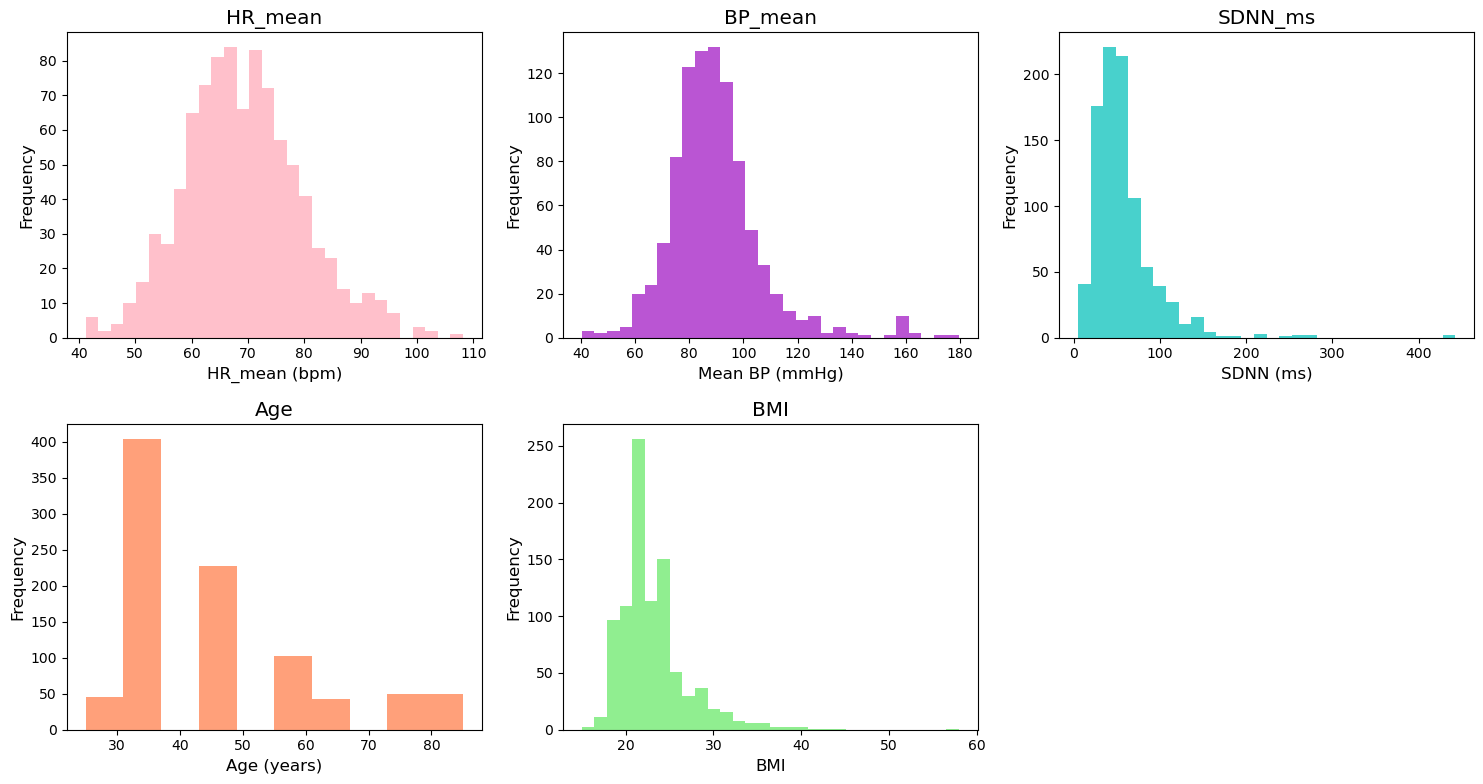

In [ ]:
# -------------------------
# Histograms as Subplots
# -------------------------

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# 1) HR_mean
axes[0].hist(merged["HR_mean"].dropna(), bins=30, color="pink")
axes[0].set_xlabel("HR_mean (bpm)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("HR_mean")

# 2) BP_mean
axes[1].hist(merged["BP_mean"].dropna(), bins=30, color="mediumorchid")
axes[1].set_xlabel("Mean BP (mmHg)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("BP_mean")

# 3) SDNN_ms
axes[2].hist(merged["SDNN_ms"].dropna(), bins=30, color="mediumturquoise")
axes[2].set_xlabel("SDNN (ms)")
axes[2].set_ylabel("Frequency")
axes[2].set_title("SDNN_ms")

# 4) Age
axes[3].hist(merged["Age"].dropna(), bins=10, color="lightsalmon")
axes[3].set_xlabel("Age (years)")
axes[3].set_ylabel("Frequency")
axes[3].set_title("Age")

# 5) BMI
axes[4].hist(merged["BMI"].dropna(), bins=30, color="lightgreen")
axes[4].set_xlabel("BMI")
axes[4].set_ylabel("Frequency")
axes[4].set_title("BMI")

# Remove empty subplot (6th position)
fig.delaxes(axes[5])

plt.tight_layout()

plt.savefig(
    FIG_DIR / "Figure_7_Histograms_Subplots.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

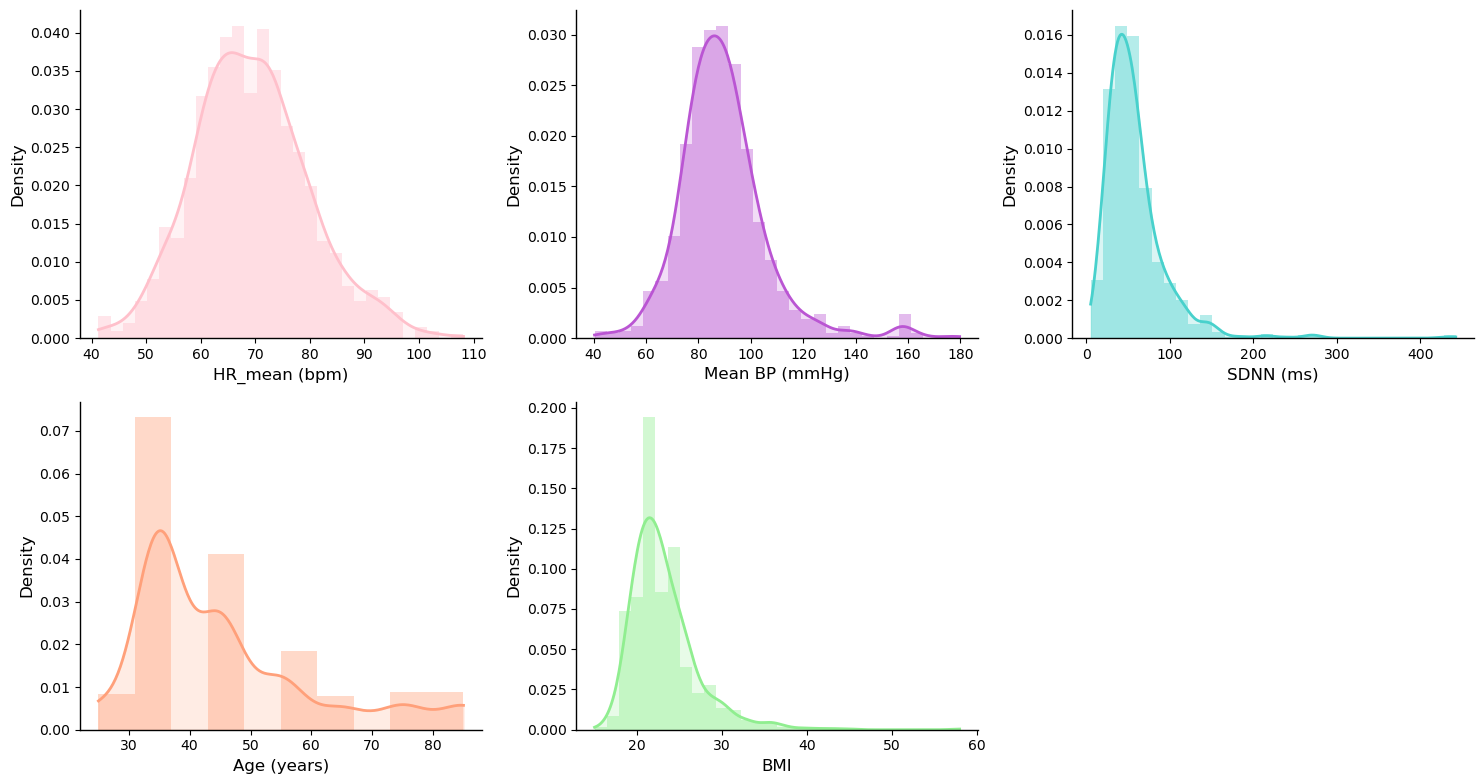

In [ ]:
# -------------------------
# Clean Thesis-Style Histograms with KDE
# -------------------------

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

def plot_hist_kde(ax, data, bins, color, xlabel):
    data = data.dropna()

    # Histogram (no borders)
    ax.hist(
        data,
        bins=bins,
        density=True,
        alpha=0.4,
        color=color,
        edgecolor=None   # ← removes bar borders
    )

    # KDE
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min(), data.max(), 300)
    y_vals = kde(x_vals)

    ax.plot(x_vals, y_vals, color=color, linewidth=2)
    ax.fill_between(x_vals, y_vals, color=color, alpha=0.2)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")

    # Remove top and right spines (no box look)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Keep only bottom and left axes
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)

# Apply to variables
plot_hist_kde(axes[0], merged["HR_mean"], 30, "pink", "HR_mean (bpm)")
plot_hist_kde(axes[1], merged["BP_mean"], 30, "mediumorchid", "Mean BP (mmHg)")
plot_hist_kde(axes[2], merged["SDNN_ms"], 30, "mediumturquoise", "SDNN (ms)")
plot_hist_kde(axes[3], merged["Age"], 10, "lightsalmon", "Age (years)")
plot_hist_kde(axes[4], merged["BMI"], 30, "lightgreen", "BMI")

# Remove empty subplot
fig.delaxes(axes[5])

plt.tight_layout()

plt.savefig(
    FIG_DIR / "Figure_7_1_Histograms_with_KDE_clean.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


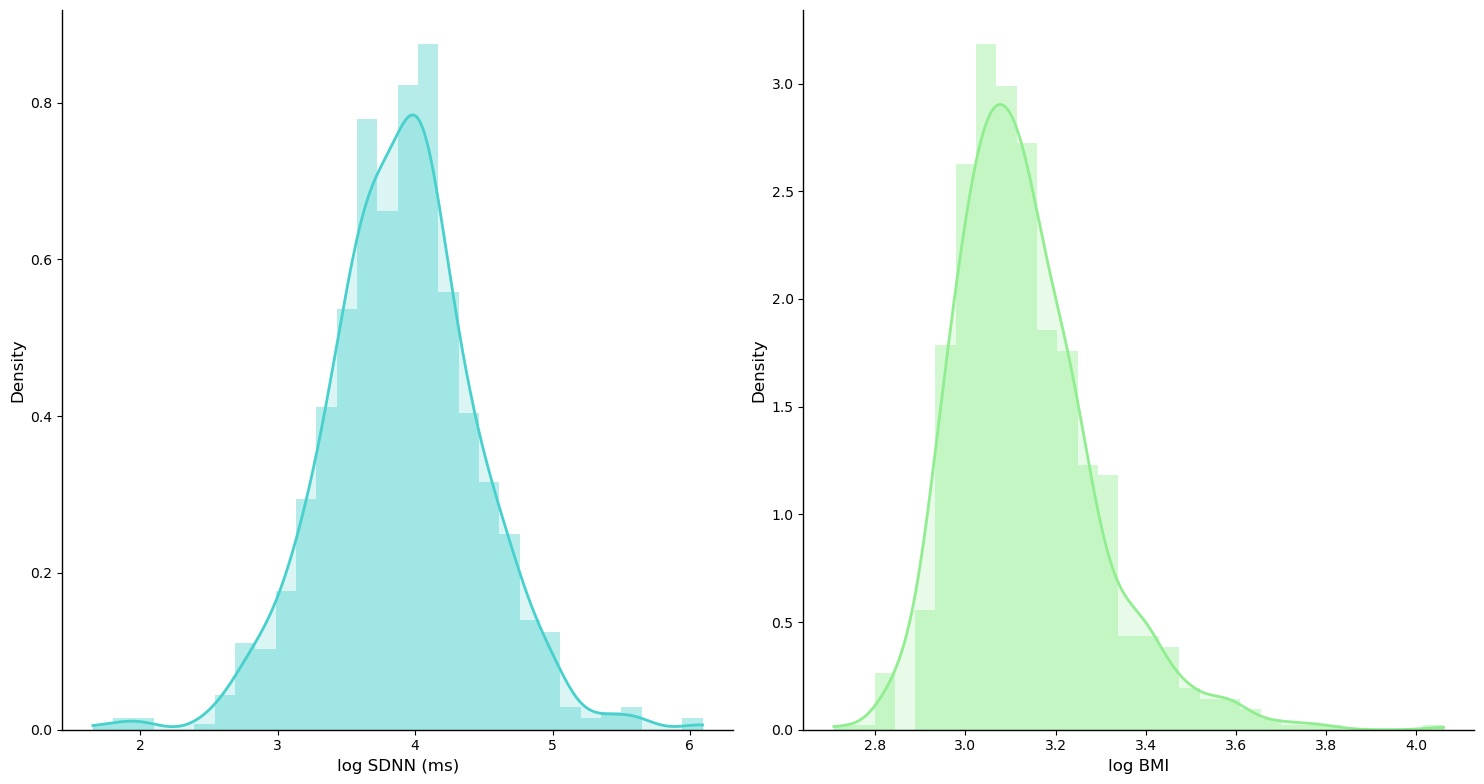

In [ ]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes = axes.flatten()

def plot_hist_kde(ax, data, bins, color, xlabel):
    data = data.dropna()

    # Histogram (no borders)
    ax.hist(
        data,
        bins=bins,
        density=True,
        alpha=0.4,
        color=color,
        edgecolor=None   # ← removes bar borders
    )

    # KDE
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min(), data.max(), 300)
    y_vals = kde(x_vals)

    ax.plot(x_vals, y_vals, color=color, linewidth=2)
    ax.fill_between(x_vals, y_vals, color=color, alpha=0.2)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")

    # Remove top and right spines (no box look)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Keep only bottom and left axes
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)

# Apply to variables
plot_hist_kde(axes[0], merged["log_SDNN"], 30, "mediumturquoise", "log SDNN (ms)")
plot_hist_kde(axes[1], merged["log_BMI"], 30, "lightgreen", "log BMI")

# Remove empty subplot


plt.tight_layout()

plt.savefig(
    FIG_DIR / "Figure_7_2_Histograms_with_KDE_clean.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [ ]:
cols_to_keep = ["HR_mean", "SDNN_ms", "log_SDNN", "BP_mean", "BMI", "log_BMI", "Age", "Sex"]
final_df = merged[[col for col in cols_to_keep if col in merged.columns]]
final_df.to_csv("final_data.csv", index=False)


print(final_df.columns)

Index(['HR_mean', 'SDNN_ms', 'log_SDNN', 'BP_mean', 'BMI', 'log_BMI', 'Age',
       'Sex'],
      dtype='object')


In [14]:
final_df.head()

,HR_mean,SDNN_ms,log_SDNN,BP_mean,BMI,log_BMI,Age,Sex
0,70.050083,57.383119,4.049750,115.711222,23.0,3.135494,35.0,1.0
1,65.779064,69.584271,4.242539,92.187697,24.0,3.178054,35.0,1.0
2,92.792893,5.226408,1.653724,95.211534,28.0,3.332205,85.0,1.0
3,62.763632,47.143751,3.853201,70.455644,24.0,3.178054,55.0,0.0
4,65.140860,66.456114,4.196542,95.577240,20.0,2.995732,35.0,1.0


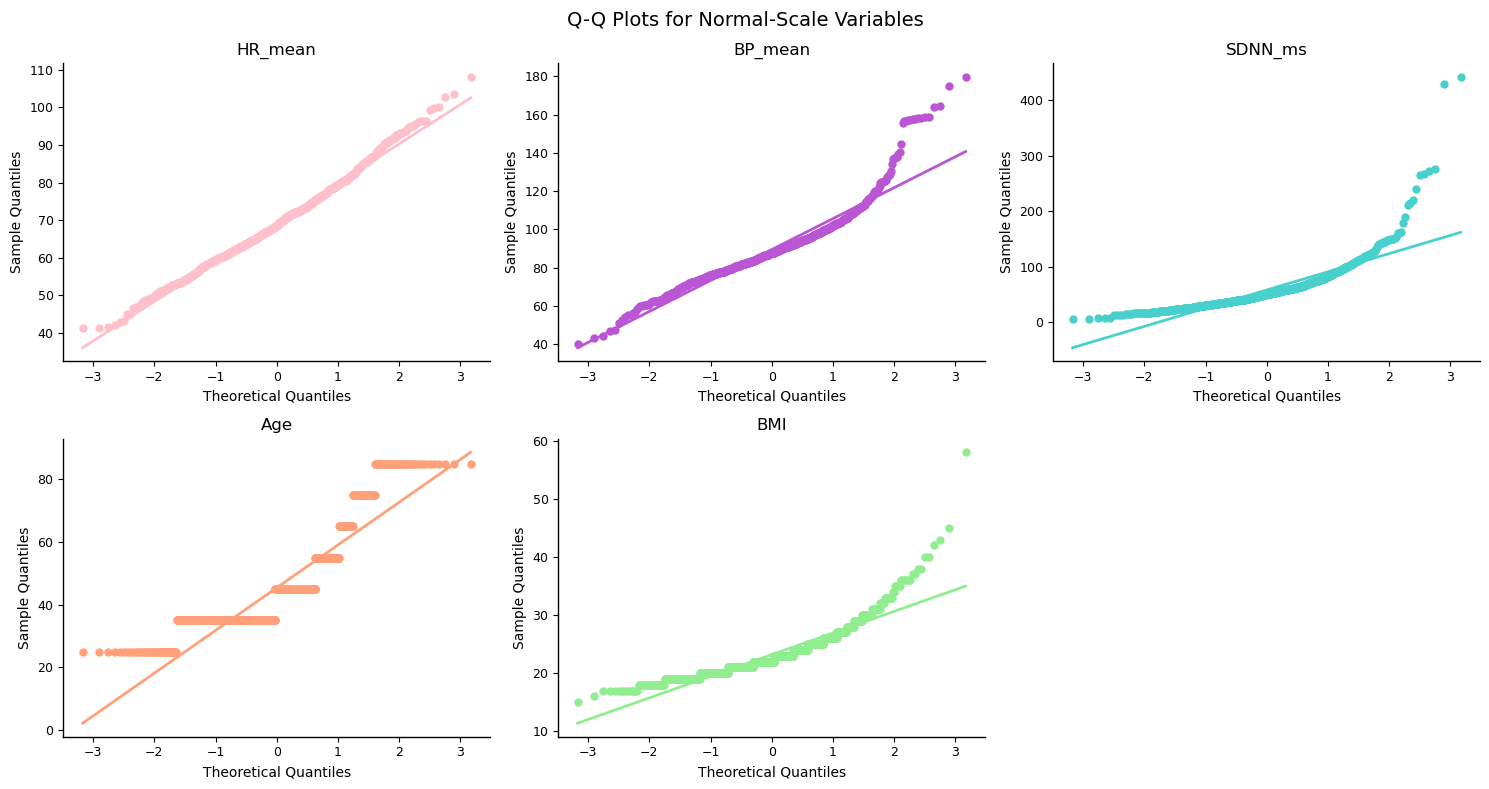

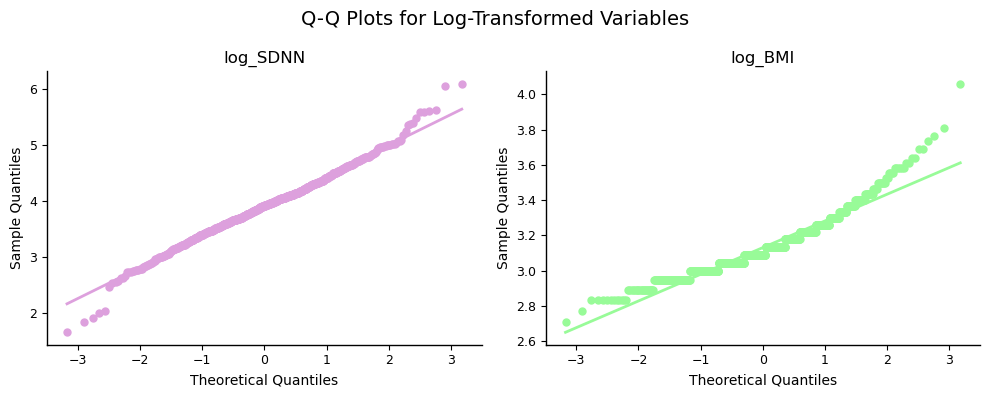

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import probplot

# -------------------------
# Column groups
# -------------------------
normal_vars = ["HR_mean", "BP_mean", "SDNN_ms", "Age", "BMI"]
log_vars = ["log_SDNN", "log_BMI"]

# Match your previous colours
colour_map = {
    "HR_mean": "pink",
    "BP_mean": "mediumorchid",
    "SDNN_ms": "mediumturquoise",
    "Age": "lightsalmon",
    "BMI": "lightgreen",
    "log_SDNN": "plum",
    "log_BMI": "palegreen"
}

# Labels
label_map = {
    "HR_mean": "HR_mean",
    "BP_mean": "BP_mean",
    "SDNN_ms": "SDNN_ms",
    "Age": "Age",
    "BMI": "BMI",
    "log_SDNN": "log_SDNN",
    "log_BMI": "log_BMI"
}

# -------------------------
# Function to style and save QQ subplots
# -------------------------
def qq_subplot(df, columns, nrows, ncols, figsize, title=None, filename=None):
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    for i, col in enumerate(columns):
        x = df[col].dropna()
        ax = axes[i]
        plot_colour = colour_map.get(col, "skyblue")

        probplot(x, dist="norm", plot=ax)

        # Recolour points and line
        lines = ax.get_lines()
        if len(lines) >= 2:
            lines[0].set_markerfacecolor(plot_colour)
            lines[0].set_markeredgecolor(plot_colour)
            lines[0].set_markersize(5)
            lines[0].set_linestyle("None")

            lines[1].set_color(plot_colour)
            lines[1].set_linewidth(2)

        # Styling
        ax.set_title(label_map.get(col, col), fontsize=12)
        ax.set_xlabel("Theoretical Quantiles", fontsize=10)
        ax.set_ylabel("Sample Quantiles", fontsize=10)
        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1)
        ax.spines["bottom"].set_linewidth(1)
        ax.tick_params(axis="both", labelsize=9)

    # Remove unused axes
    for j in range(len(columns), len(axes)):
        fig.delaxes(axes[j])

    if title is not None:
        fig.suptitle(title, fontsize=14)

    plt.tight_layout()

    if filename is not None:
        plt.savefig(
            FIG_DIR / filename,
            format="pdf",
            bbox_inches="tight"
        )

    plt.show()


# -------------------------
# Save QQ subplot for normal variables
# -------------------------
qq_subplot(
    df=final_df,
    columns=normal_vars,
    nrows=2,
    ncols=3,
    figsize=(15, 8),
    #title="Q-Q Plots for Normal-Scale Variables",
    filename="QQPlots_NormalVariables.pdf"
)

# -------------------------
# Save QQ subplot for log variables
# -------------------------
qq_subplot(
    df=final_df,
    columns=log_vars,
    nrows=1,
    ncols=2,
    figsize=(10, 4),
    #title="Q-Q Plots for Log-Transformed Variables",
    filename="QQPlots_LogVariables.pdf"
)


In [ ]:
def check_gaussian_columns_summary(df, max_shapiro_n=5000):
    numeric_df = df.select_dtypes(include=[np.number])
    results = []

    for col in numeric_df.columns:
        x = numeric_df[col].dropna()
        if len(x) < 3:
            continue

        x_shapiro = x.sample(max_shapiro_n, random_state=42) if len(x) > max_shapiro_n else x
        _, p = shapiro(x_shapiro)
        s = skew(x)
        k = kurtosis(x)

        if p > 0.05:
            interpretation = "Consistent with Gaussian"
        else:
            interpretation = "Evidence against Gaussian"

        results.append({
            "column": col,
            "n": len(x),
            "skewness": round(s, 3),
            "excess_kurtosis": round(k, 3),
            "shapiro_p_value": round(p, 5),
            "interpretation": interpretation
        })

    return pd.DataFrame(results)

In [ ]:
results = check_gaussian_columns_summary(final_df)
print(results)

     column    n  skewness  excess_kurtosis  shapiro_p_value  \
0   HR_mean  920     0.325            0.256          0.00018   
1   SDNN_ms  920     3.662           25.211          0.00000   
2  log_SDNN  920     0.005            1.137          0.00002   
3   BP_mean  920     1.398            4.674          0.00000   
4       BMI  920     2.083            9.054          0.00000   
5   log_BMI  920     1.083            2.467          0.00000   
6       Age  920     1.240            0.771          0.00000   
7       Sex  920    -0.493           -1.757          0.00000   

              interpretation  
0  Evidence against Gaussian  
1  Evidence against Gaussian  
2  Evidence against Gaussian  
3  Evidence against Gaussian  
4  Evidence against Gaussian  
5  Evidence against Gaussian  
6  Evidence against Gaussian  
7  Evidence against Gaussian  
